## Importing Libraries

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os

In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
import tensorflow as tf
print(tf.__version__)


2.10.0


In [6]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))


PyTorch version: 2.5.1+cu121
CUDA available: True
GPU Name: NVIDIA GeForce GTX 1050 Ti


In [ ]:
import torch
print(torch.cuda.get_device_nam3(0))

In [ ]:
print(tf.config.list_physical_devices('GPU'))

In [5]:
def find_empty_files(folder_path):
    empty_files = []

    for root, dirs, files in os.walk(folder_path):
        for file in files:
            file_path = os.path.join(root, file)
            if os.path.getsize(file_path) == 0:
                empty_files.append(file_path)

    return empty_files

# Replace with your actual full paths
train_folder = r'Crops_disease_detection\train'
valid_folder = r'Crops_disease_detection\valid'

train_empty_files = find_empty_files(train_folder)
valid_empty_files = find_empty_files(valid_folder)

# Print results
print("Empty files in train folder:")
print("\n".join(train_empty_files) if train_empty_files else "No empty files found.")

print("\nEmpty files in valid folder:")
print("\n".join(valid_empty_files) if valid_empty_files else "No empty files found.")


Empty files in train folder:
No empty files found.

Empty files in valid folder:
No empty files found.


## Data Preprocessing

###  Training Image Preprocessing

In [6]:
training_set = tf.keras.utils.image_dataset_from_directory(
    'train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(224, 224),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 18228 files belonging to 16 classes.


### Validation Image Preprocessing

In [7]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(224, 224),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 11820 files belonging to 16 classes.


In [8]:
training_set

<BatchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 16), dtype=tf.float32, name=None))>

In [9]:
for x,y in training_set:
    print(x, x.shape)
    print(y, y.shape)
    break

tf.Tensor(
[[[[ 10.79082    10.51531    21.79082  ]
   [148.92857   146.92857   160.14287  ]
   [148.78572   146.42857   161.5      ]
   ...
   [134.52058   122.520584  132.52058  ]
   [135.5714    123.57139   133.5714   ]
   [134.68369   122.68368   132.68369  ]]

  [[ 13.4285755  11.4285755  24.428574 ]
   [152.38264   150.38264   163.59694  ]
   [152.07143   149.71428   164.7857   ]
   ...
   [118.64801   106.64801   116.64801  ]
   [122.99492   110.99492   120.99492  ]
   [137.97476   125.974754  135.97476  ]]

  [[ 11.9285755  10.591841   22.928574 ]
   [150.63776   148.63776   161.85204  ]
   [149.42857   147.07143   162.14285  ]
   ...
   [124.48468   112.48468   122.48468  ]
   [117.82648   105.82648   115.82648  ]
   [122.31134   110.31134   120.31134  ]]

  ...

  [[  9.479593    8.336736   17.479593 ]
   [119.16323   115.94895   127.591805 ]
   [118.95401   114.95401   128.95401  ]
   ...
   [139.84181   128.84181   142.84181  ]
   [133.85709   122.857086  136.85709  ]
   [1

### Excess Green (ExG), Excess Red (ExR) & Principal Component Analysis (PCA)

In [10]:
!pip install tqdm

In [11]:
from tensorflow.keras.utils import Sequence
from sklearn.decomposition import PCA
from tqdm import tqdm
import numpy as np

In [12]:
class FiveChannelPCADataGenerator(Sequence):
    def __init__(self, folder, batch_size=32, img_size=(224,224), shuffle=True, pca_components=None, sample_pca=100):
        self.folder = folder
        self.classes = sorted(os.listdir(folder))
        self.files = []
        self.labels = []
        for idx, cls in enumerate(self.classes):
            cls_path = os.path.join(folder, cls)
            for f in os.listdir(cls_path):
                if f.lower().endswith((".jpg",".png",".jpeg")):
                    self.files.append(os.path.join(cls_path, f))
                    self.labels.append(idx)
        self.batch_size = batch_size
        self.img_size = img_size
        self.shuffle = shuffle
        self.pca_components = pca_components
        self.pca = None
        if pca_components:
            self._fit_pca(folder, sample_pca)
        self.on_epoch_end()
        
    def _fit_pca(self, folder, sample_pca):
        print("Fitting PCA on sample images...")
        samples = []
        count = 0
        for cls in os.listdir(folder):
            cls_path = os.path.join(folder, cls)
            for f in os.listdir(cls_path):
                if f.lower().endswith((".jpg",".png",".jpeg")):
                    img = cv2.imread(os.path.join(cls_path, f))
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    img = cv2.resize(img, self.img_size).astype(np.float32)
                    R,G,B = img[:,:,0], img[:,:,1], img[:,:,2]
                    ExG = np.clip(2*G - R - B, 0, 255)
                    ExR = np.clip(1.4*R - G, 0, 255)
                    img_5ch = np.stack([R,G,B,ExG,ExR], axis=-1)
                    img_flat = img_5ch.reshape(-1,5)
                    samples.append(img_flat)
                    count += 1
                    if count >= sample_pca:
                        break
            if count >= sample_pca:
                break
        all_samples = np.concatenate(samples, axis=0)
        self.pca = PCA(n_components=self.pca_components)
        self.pca.fit(all_samples)
        print("PCA fitted with components =", self.pca_components)
        
    def __len__(self):
        return int(np.ceil(len(self.files)/self.batch_size))
    
    def on_epoch_end(self):
        if self.shuffle:
            temp = list(zip(self.files, self.labels))
            np.random.shuffle(temp)
            self.files, self.labels = zip(*temp)
    
    def __getitem__(self, idx):
        batch_files = self.files[idx*self.batch_size : (idx+1)*self.batch_size]
        batch_labels = [self.labels[i] for i in range(idx*self.batch_size, min((idx+1)*self.batch_size, len(self.files)))]
        batch_images = [self._process_image(f) for f in batch_files]
        return np.array(batch_images, dtype=np.float32), np.array(batch_labels)
    
    def _process_image(self, path):
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, self.img_size).astype(np.float32)
        R,G,B = img[:,:,0], img[:,:,1], img[:,:,2]
        ExG = np.clip(2*G - R - B, 0, 255)
        ExR = np.clip(1.4*R - G, 0, 255)
        img_5ch = np.stack([R,G,B,ExG,ExR], axis=-1)
        
        if self.pca:
            H,W,C = img_5ch.shape
            img_flat = img_5ch.reshape(-1,C)
            img_pca = self.pca.transform(img_flat).reshape(H,W,self.pca_components)
            img_5ch = img_pca
        
        img_5ch /= 255.0  # normalize
        return img_5ch


In [13]:
train_gen = FiveChannelPCADataGenerator(
    r"C:\Users\asus\Desktop\Crops_disease_detection\train",
    batch_size=32,
    img_size=(224,224),
    shuffle=True,
    pca_components=None   # or try 3 if you want PCA
)

valid_gen = FiveChannelPCADataGenerator(
    r"C:\Users\asus\Desktop\Crops_disease_detection\valid",
    batch_size=32,
    img_size=(224,224),
    shuffle=False,
    pca_components=None
)

test_gen = FiveChannelPCADataGenerator(
    r"C:\Users\asus\Desktop\Crops_disease_detection\test",
    batch_size=32,
    img_size=(224,224),
    shuffle=False,
    pca_components=None
)


## Building Model

In [14]:
from tensorflow.keras.layers import Dense,Conv2D,MaxPool2D,Flatten,Dropout,BatchNormalization
from tensorflow.keras.models import Sequential

In [15]:
model = Sequential()

## Building Convolution Layer

In [16]:
model.add(Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[224,224,5]))
model.add(Conv2D(filters=32,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))
model.add(BatchNormalization())

In [17]:
model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=64,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))
model.add(BatchNormalization())

In [18]:
model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=128,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))
model.add(BatchNormalization())

In [19]:
model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=256,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))
model.add(BatchNormalization())

In [20]:
model.add(Dropout(0.25)) #To avoid Overfitting

In [21]:
from tensorflow.keras.layers import GlobalAveragePooling2D
model.add(GlobalAveragePooling2D())

In [22]:
model.add(Dense(units=256,activation='relu'))

In [23]:
model.add(Dropout(0.4))

In [24]:
## Output Layer
model.add(Dense(units=16,activation='softmax'))

## Compiling Model

In [25]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [26]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 224, 224, 32)      1472      
                                                                 
 conv2d_1 (Conv2D)           (None, 222, 222, 32)      9248      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 111, 111, 32)     0         
 )                                                               
                                                                 
 batch_normalization (BatchN  (None, 111, 111, 32)     128       
 ormalization)                                                   
                                                                 
 conv2d_2 (Conv2D)           (None, 111, 111, 64)      18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 109, 109, 64)      3

## Model Training

In [27]:
import cv2

In [28]:
# Add EarlyStopping to avoid overfitting
#from tensorflow.keras.callbacks import EarlyStopping

#early_stop = EarlyStopping(
    #monitor="val_loss",
    #patience=3,
    #restore_best_weights=True
#)

# Train with early stopping
training_history = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=20,                 
    #callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
570/570 [==============================] - 287s 486ms/step - loss: 1.7699 - accuracy: 0.4660 - val_loss: 1.7677 - val_accuracy: 0.3786
Epoch 2/20
570/570 [==============================] - 272s 477ms/step - loss: 1.1903 - accuracy: 0.6302 - val_loss: 1.1295 - val_accuracy: 0.6284
Epoch 3/20
570/570 [==============================] - 280s 491ms/step - loss: 0.9888 - accuracy: 0.6847 - val_loss: 0.9681 - val_accuracy: 0.6838
Epoch 4/20
570/570 [==============================] - 271s 474ms/step - loss: 0.8569 - accuracy: 0.7267 - val_loss: 0.8410 - val_accuracy: 0.7318
Epoch 5/20
570/570 [==============================] - 271s 476ms/step - loss: 0.7603 - accuracy: 0.7610 - val_loss: 0.7422 - val_accuracy: 0.7654
Epoch 6/20
570/570 [==============================] - 269s 472ms/step - loss: 0.6845 - accuracy: 0.7791 - val_loss: 0.6777 - val_accuracy: 0.7838
Epoch 7/20
570/570 [==============================] - 270s 473ms/step - loss: 0.6278 - accuracy: 0.7978 - val_loss: 0.6117 -

In [29]:
num_classes = len(training_set.class_names)
print("Classes:", training_set.class_names, " | Count:", num_classes)

Classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'CottonAphids', 'CottonArmy_worm', 'CottonBacterial_Blight', 'CottonHealthy', 'CottonPowdery_Mildew', 'CottonTarget_spot', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'RoseBlack Spot', 'RoseDowny Mildew', 'RoseFresh Leaf']  | Count: 16


## Model Evaluation

In [30]:
# Model Evaluation on Training set
train_loss,train_acc = model.evaluate(train_gen)

570/570 [==============================] - 134s 234ms/step - loss: 0.1982 - accuracy: 0.9391


In [31]:
print(train_loss,train_acc)

0.19819949567317963 0.9391046762466431


In [32]:
# Model on Validation set
val_loss,val_acc = model.evaluate(valid_gen)

369/369 [==============================] - 103s 280ms/step - loss: 0.2808 - accuracy: 0.9107


In [33]:
print(val_loss,val_acc)

0.2808426320552826 0.910677969455719


## Saving model

In [34]:
model.save("cnn_crops_trained_model.keras")

In [35]:
training_history.history

{'loss': [1.7699329853057861,
  1.1903495788574219,
  0.9887704849243164,
  0.8569120764732361,
  0.7603340744972229,
  0.6844945549964905,
  0.6278238892555237,
  0.5780779123306274,
  0.5456194877624512,
  0.5115372538566589,
  0.47538748383522034,
  0.448377788066864,
  0.4310857355594635,
  0.4109300971031189,
  0.38736504316329956,
  0.3695337474346161,
  0.3469056785106659,
  0.3317410945892334,
  0.3179042637348175,
  0.3088822364807129],
 'accuracy': [0.4659864008426666,
  0.6302391886711121,
  0.6847158074378967,
  0.7266842126846313,
  0.7609721422195435,
  0.7791309952735901,
  0.797783613204956,
  0.8149549961090088,
  0.8263660073280334,
  0.8367895483970642,
  0.8467742204666138,
  0.8594470024108887,
  0.8637809753417969,
  0.8680601119995117,
  0.8749176859855652,
  0.8820496201515198,
  0.8885231614112854,
  0.8942286372184753,
  0.8990015387535095,
  0.9013056755065918],
 'val_loss': [1.7676770687103271,
  1.1295127868652344,
  0.9681168794631958,
  0.8409649729728699

In [36]:
# Recording History in json
import json
with open ("training_hist.json","w") as f:
    json.dump(training_history.history,f)
    

In [37]:
training_history.history['val_accuracy']

[0.37864407896995544,
 0.628389835357666,
 0.6838135719299316,
 0.7317796349525452,
 0.7654237151145935,
 0.7838135361671448,
 0.8059322237968445,
 0.8123728632926941,
 0.8405084609985352,
 0.8452542424201965,
 0.8550000190734863,
 0.8592373132705688,
 0.8695762753486633,
 0.8757627010345459,
 0.879406750202179,
 0.8894914984703064,
 0.9023728966712952,
 0.902203381061554,
 0.9061864614486694,
 0.910677969455719]

## Accuracy Visualisation

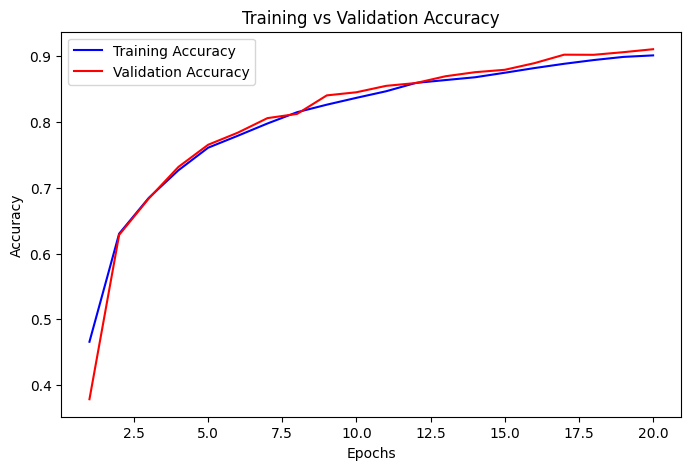

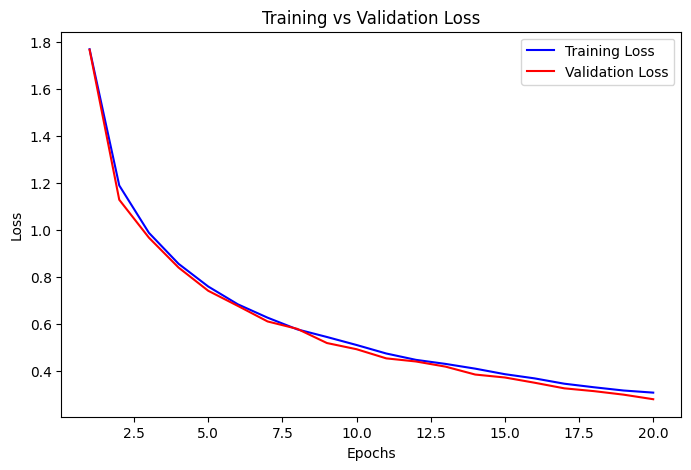

In [38]:
# Automatically get the number of epochs from training history
epochs = range(1, len(training_history.history['accuracy']) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs, training_history.history['accuracy'], color='blue', label='Training Accuracy')
plt.plot(epochs, training_history.history['val_accuracy'], color='red', label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

# Optional: plot loss too
plt.figure(figsize=(8,5))
plt.plot(epochs, training_history.history['loss'], color='blue', label='Training Loss')
plt.plot(epochs, training_history.history['val_loss'], color='red', label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

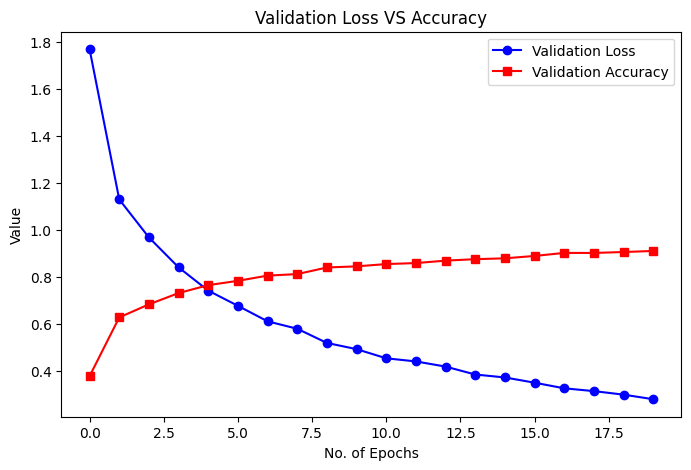

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(training_history.history['val_loss'], label='Validation Loss', marker='o', color='blue')
plt.plot(training_history.history['val_accuracy'], label='Validation Accuracy', marker='s', color='red')

plt.xlabel('No. of Epochs')
plt.ylabel('Value')
plt.title('Validation Loss VS Accuracy')
plt.legend()
plt.show()

### Some Other Metrices for Model Evaluation

In [40]:
# Use the same custom generator as training/validation
valid_gen = FiveChannelPCADataGenerator(
    r"C:\Users\asus\Desktop\Crops_disease_detection\valid",  # or test folder
    batch_size=32,
    img_size=(224, 224),
    pca_components=None,
    shuffle=False   # VERY IMPORTANT for correct label alignment
)

In [41]:
import tensorflow as tf

model = tf.keras.models.load_model("cnn_crops_trained_model.keras")


In [42]:
# Predict probabilities for each class
y_pred_proba = model.predict(valid_gen)

# Convert probabilities to predicted class indices
y_pred = np.argmax(y_pred_proba, axis=1)


369/369 [==============================] - 101s 274ms/step


In [43]:
import numpy as np

# Concatenate all batches from generator
y_true = np.concatenate([y for x, y in valid_gen], axis=0)

# If generator yields one-hot labels, convert to class indices
if y_true.ndim > 1:
    y_true = np.argmax(y_true, axis=1)


In [44]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_true, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9106779661016949


In [45]:
from sklearn.metrics import precision_score
precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
print("Precision (weighted):", precision)

Precision (weighted): 0.9104517673412605


In [46]:
from sklearn.metrics import recall_score
recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
print("Recall (weighted):", recall)

Recall (weighted): 0.9106779661016949


In [47]:
from sklearn.metrics import f1_score
f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
print("F1-score (weighted):", f1)

F1-score (weighted): 0.9102832191540894


In [48]:
from sklearn.metrics import roc_auc_score
import tensorflow as tf

y_true_onehot = tf.keras.utils.to_categorical(y_true, num_classes=y_pred_proba.shape[1])
roc_auc = roc_auc_score(y_true_onehot, y_pred_proba, multi_class="ovr", average="weighted")
print("ROC-AUC (weighted OVR):", roc_auc)

ROC-AUC (weighted OVR): 0.9949962834569605


In [49]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_true_onehot, y_pred_proba))
print("RMSE:", rmse)

RMSE: 0.09147869


### Metrices

In [50]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=training_set.class_names, zero_division=0))

                          precision    recall  f1-score   support

      Apple___Apple_scab       0.96      0.96      0.96       504
       Apple___Black_rot       0.99      0.98      0.99       497
Apple___Cedar_apple_rust       0.98      1.00      0.99       440
         Apple___healthy       0.95      0.99      0.97       502
            CottonAphids       0.88      0.93      0.90      1440
         CottonArmy_worm       0.92      0.89      0.90      1440
  CottonBacterial_Blight       0.86      0.88      0.87      1440
           CottonHealthy       0.94      0.93      0.93      1440
    CottonPowdery_Mildew       0.96      0.97      0.96      1440
       CottonTarget_spot       0.86      0.84      0.85      1440
   Potato___Early_blight       0.95      0.96      0.96       100
    Potato___Late_blight       0.90      0.82      0.86       100
        Potato___healthy       1.00      0.95      0.97       100
          RoseBlack Spot       0.77      0.68      0.72       313
        R

### Confusion Matrix Visualisation

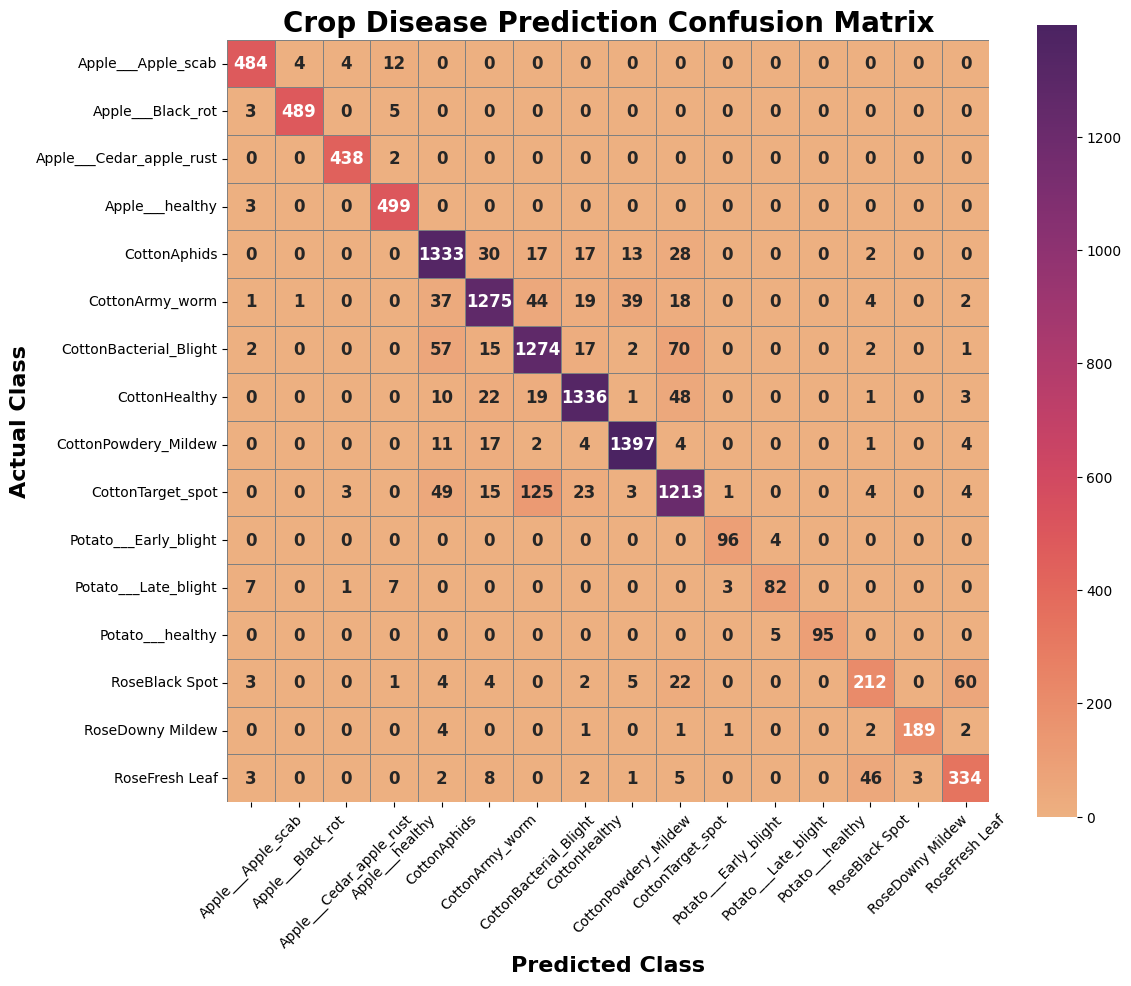

In [51]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12,10))

# Gradient colors
cmap = sns.color_palette("flare", as_cmap=True)

sns.heatmap(cm, annot=True, fmt="d", cmap=cmap,
            xticklabels=training_set.class_names, yticklabels=training_set.class_names,
            annot_kws={"size": 12, "weight": "bold"},
            cbar=True, linewidths=0.5, linecolor='gray', square=True)

plt.xlabel("Predicted Class", fontsize=16, weight="bold")
plt.ylabel("Actual Class", fontsize=16, weight="bold")
plt.title("Crop Disease Prediction Confusion Matrix", fontsize=20, weight="bold")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


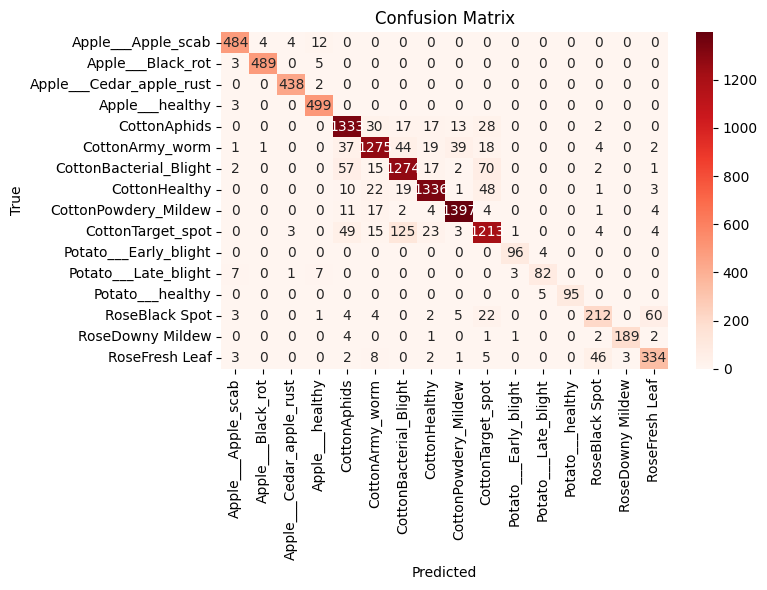

In [52]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds", xticklabels=training_set.class_names, yticklabels=training_set.class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


## ROC–AUC Curve Plot (Multi-class)

C:\Users\asus\AppData\Local\Temp\ipykernel_8080\1452143987.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('tab10', num_classes)


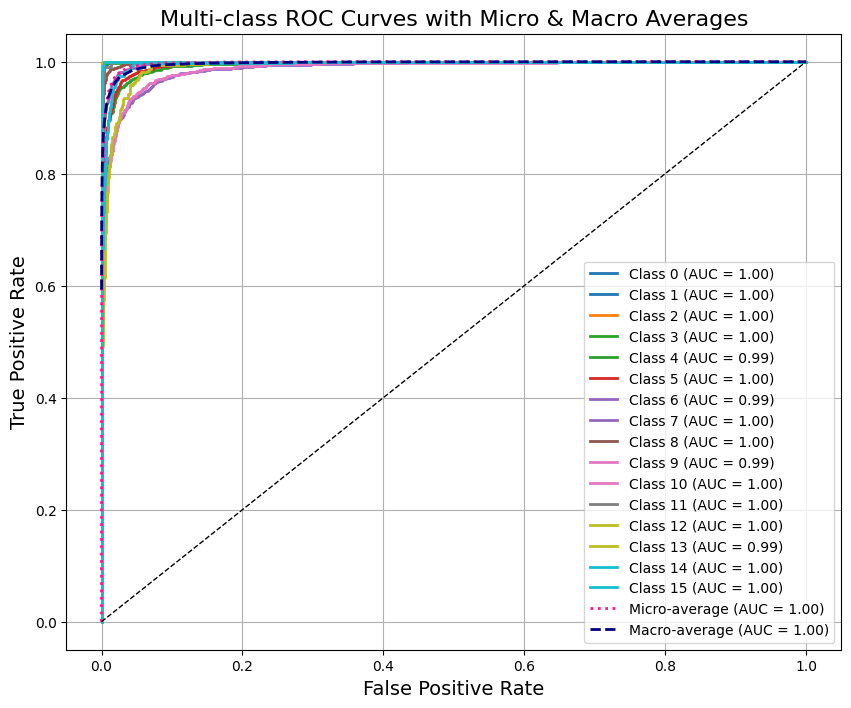

In [53]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# y_true and y_pred_proba already prepared
y_true_onehot = tf.keras.utils.to_categorical(y_true, num_classes=y_pred_proba.shape[1])
num_classes = y_pred_proba.shape[1]

# Per-class ROC
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_onehot[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Micro-average
fpr_micro, tpr_micro, _ = roc_curve(y_true_onehot.ravel(), y_pred_proba.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)

# Macro-average
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(num_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(num_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= num_classes
roc_auc_macro = auc(all_fpr, mean_tpr)

# Plot ROC curves
plt.figure(figsize=(10,8))
colors = plt.cm.get_cmap('tab10', num_classes)
for i, color in zip(range(num_classes), colors.colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f"Class {i} (AUC = {roc_auc[i]:.2f})")
plt.plot(fpr_micro, tpr_micro, color='deeppink', lw=2, linestyle=':',
         label=f'Micro-average (AUC = {roc_auc_micro:.2f})')
plt.plot(all_fpr, mean_tpr, color='navy', lw=2, linestyle='--',
         label=f'Macro-average (AUC = {roc_auc_macro:.2f})')
plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlabel("False Positive Rate", fontsize=14)
plt.ylabel("True Positive Rate", fontsize=14)
plt.title("Multi-class ROC Curves with Micro & Macro Averages", fontsize=16)
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


## ROC–AUC Curve Plot 

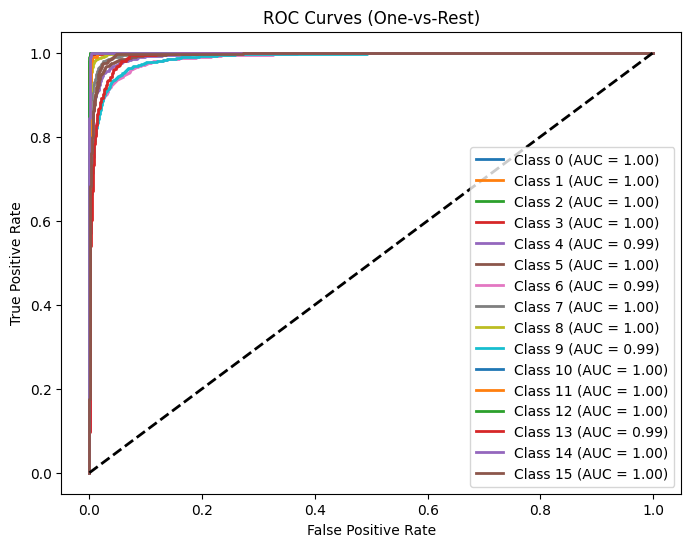

In [54]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# Convert true labels to one-hot if needed
y_true_onehot = tf.keras.utils.to_categorical(y_true, num_classes=y_pred_proba.shape[1])
num_classes = y_pred_proba.shape[1]

plt.figure(figsize=(8, 6))

# Plot ROC curve for each class (One-vs-Rest)
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_onehot[:, i], y_pred_proba[:, i])
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"Class {i} (AUC = {auc_score:.2f})")

# Diagonal line for random classifier
plt.plot([0, 1], [0, 1], "k--", lw=2)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (One-vs-Rest)")
plt.legend(loc="lower right")
plt.show()

## Test set metrices

In [55]:
import os

test_folder = r"C:\Users\asus\Desktop\Crops_disease_detection\test"
print(os.listdir(test_folder))  # should show subfolders (disease categories)

['.ipynb_checkpoints', 'AppleBlackRot', 'AppleCedarRust', 'AppleScab', 'CottonAphids', 'CottonArmy_worm', 'CottonBacterial_Blight', 'CottonHealthy', 'CottonPowdery_Mildew', 'CottonTarget_spot', 'Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight', 'RoseBlack Spot', 'RoseDowny Mildew', 'RoseFresh Leaf']


In [56]:
test_folder = r"C:\Users\asus\Desktop\Crops_disease_detection\test"

test_gen = FiveChannelPCADataGenerator(
    folder=test_folder,
    batch_size=32,
    img_size=(224,224),
    shuffle=False,
    pca_components=None
)

print("Number of test batches:", len(test_gen))

# Check first batch
x_test, y_test = test_gen[0]
print("Test batch shape:", x_test.shape, y_test.shape)
print("Unique classes in this batch:", np.unique(y_test))


Number of test batches: 44
Test batch shape: (32, 224, 224, 5) (32,)
Unique classes in this batch: [1 2 3 4]


In [57]:
x_test, y_test = test_gen[0]  # get first batch
print(x_test.shape, y_test.shape)

(32, 224, 224, 5) (32,)


44/44 [==============================] - 24s 540ms/step
Accuracy: 0.8546
Precision (Macro): 0.7566
Recall (Macro): 0.7685
F1-score (Macro): 0.7595
RMSE: 1.7763


C:\Users\asus\miniconda3\envs\tf\lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


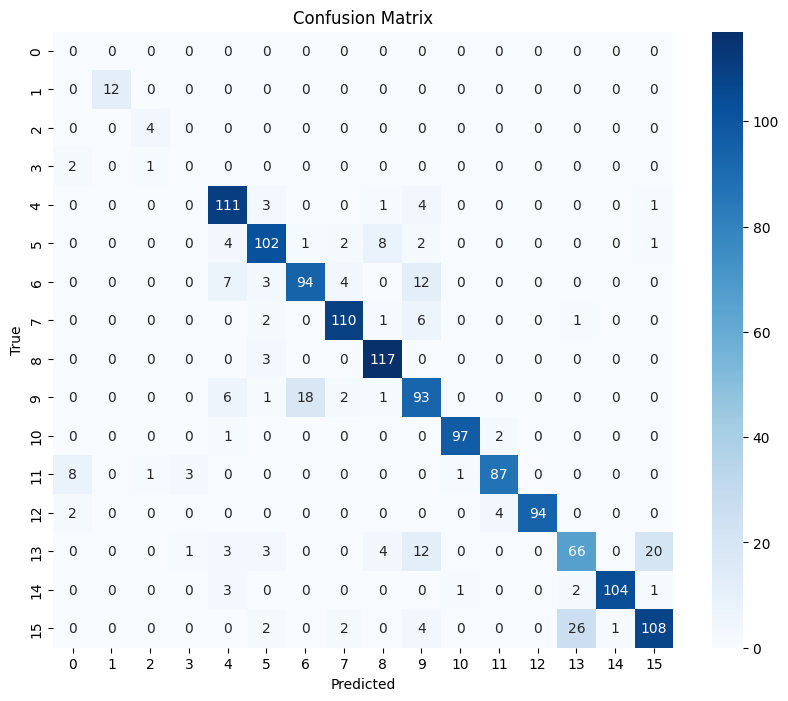

In [58]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Get all test data
x_test = np.concatenate([x for x, y in test_gen], axis=0)
y_true = np.concatenate([y for x, y in test_gen], axis=0)

# 2️⃣ Predict
y_pred_proba = model.predict(test_gen)
y_pred = np.argmax(y_pred_proba, axis=1)

# 3️⃣ Metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')
rmse = np.sqrt(np.mean((y_true - y_pred)**2))

# 5️⃣ Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# 6️⃣ Print metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (Macro): {precision:.4f}")
print(f"Recall (Macro): {recall:.4f}")
print(f"F1-score (Macro): {f1:.4f}")
print(f"RMSE: {rmse:.4f}")

# 7️⃣ Plot Confusion Matrix
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

## Training vs Validation Graphs (Accuracy & Loss)

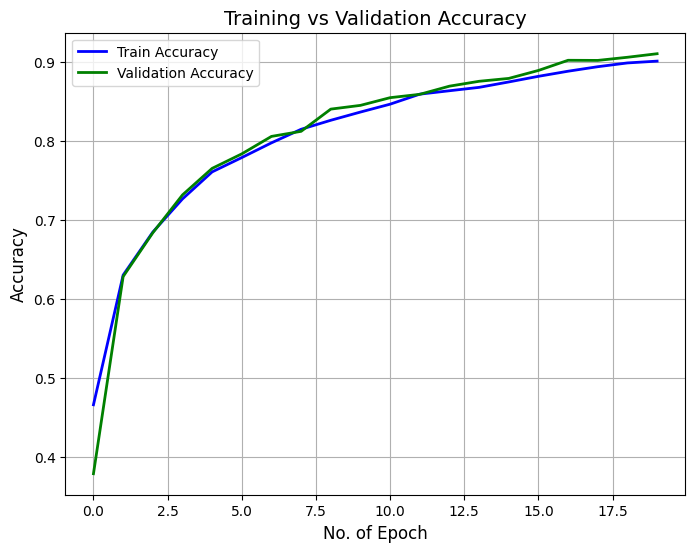

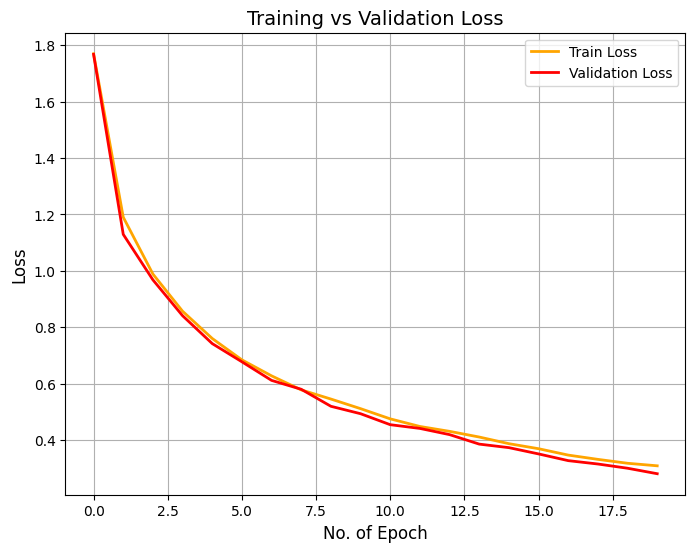

In [59]:
import matplotlib.pyplot as plt

# history.history = {'loss': [...], 'val_loss': [...], 'accuracy': [...], 'val_accuracy': [...]}
history_dict = training_history.history

# Accuracy
plt.figure(figsize=(8,6))
plt.plot(history_dict['accuracy'], label='Train Accuracy', color='blue', lw=2)
plt.plot(history_dict['val_accuracy'], label='Validation Accuracy', color='green', lw=2)
plt.xlabel('No. of Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Training vs Validation Accuracy', fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.figure(figsize=(8,6))
plt.plot(history_dict['loss'], label='Train Loss', color='orange', lw=2)
plt.plot(history_dict['val_loss'], label='Validation Loss', color='red', lw=2)
plt.xlabel('No. of Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training vs Validation Loss', fontsize=14)
plt.legend()
plt.grid(True)
plt.show()


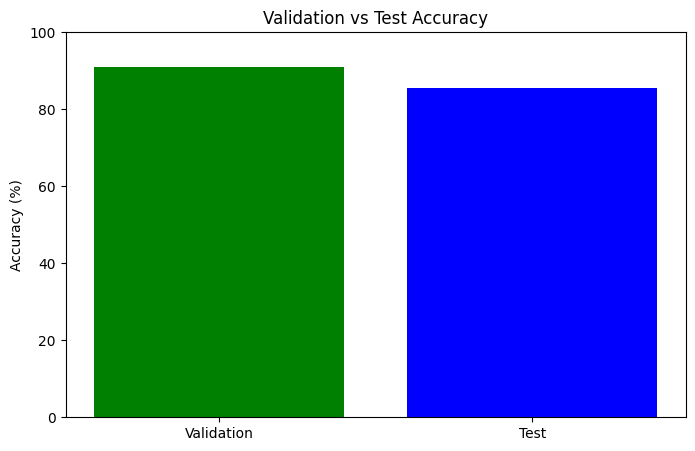

In [60]:
import matplotlib.pyplot as plt

# Validation metrics from history
val_acc = training_history.history['val_accuracy'][-1]  # Last epoch
val_loss = training_history.history['val_loss'][-1]     # Last epoch

# Plot Accuracy
plt.figure(figsize=(8,5))
plt.bar(['Validation', 'Test'], [val_acc*100, accuracy*100], color=['green', 'blue'])
plt.ylabel("Accuracy (%)")
plt.title("Validation vs Test Accuracy")
plt.ylim(0, 100)
plt.show()



### ExR and ExG Plot

In [61]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [62]:
# Load an image (ensure it is RGB)
img = cv2.imread("valid/Apple___Black_rot/0bc40cc3-6a85-480e-a22f-967a866a56a1___JR_FrgE.S 2784_270deg.JPG")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # convert BGR to RGB
img = img.astype(np.float32)


In [63]:
R = img[:,:,0]
G = img[:,:,1]
B = img[:,:,2]

# Excess Green
ExG = 2*G - R - B

# Excess Red
ExR = 1.4*R - G


In [64]:
ExG_norm = (ExG - ExG.min()) / (ExG.max() - ExG.min())
ExR_norm = (ExR - ExR.min()) / (ExR.max() - ExR.min())


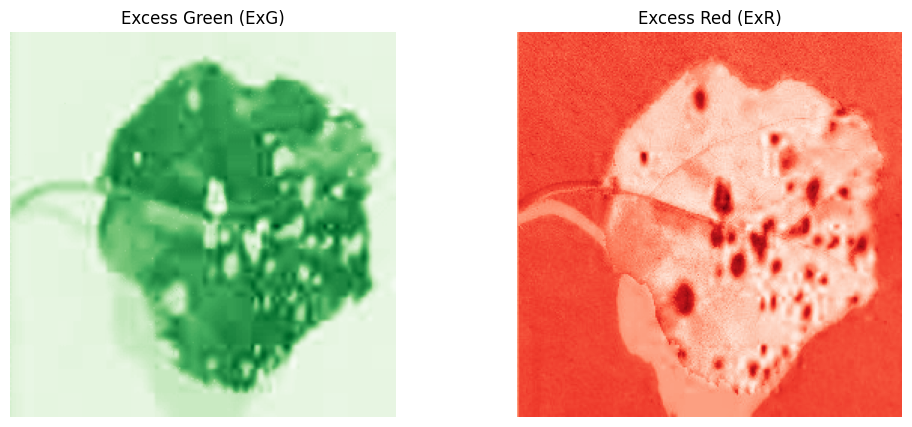

In [65]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(ExG_norm, cmap='Greens')
plt.title("Excess Green (ExG)")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(ExR_norm, cmap='Reds')
plt.title("Excess Red (ExR)")
plt.axis('off')

plt.show()


In [ ]:
import matplotlib.pyplot as plt

# ================== IEEE-Style Two-Panel Figure ==================
plt.figure(figsize=(6, 3))  # Adjusted for IEEE single-column figure

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 9,
    "axes.linewidth": 0.8
})

# ---------- Panel 1: ExG ----------
plt.subplot(1, 2, 1)
plt.imshow(ExG_norm, cmap='Greens')
plt.title("Excess Green (ExG)", fontsize=10, fontweight='bold')
plt.axis('off')

# ---------- Panel 2: ExR ----------
plt.subplot(1, 2, 2)
plt.imshow(ExR_norm, cmap='Reds')
plt.title("Excess Red (ExR)", fontsize=10, fontweight='bold')
plt.axis('off')

plt.tight_layout()

# ================== Save Figures ==================
plt.savefig("ExG_ExR_ieee.pdf", format="pdf", bbox_inches="tight", dpi=600)
plt.savefig("ExG_ExR_ieee.png", format="png", bbox_inches="tight", dpi=300)

plt.show()


In [66]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt


In [67]:
image_path = r"valid/Apple___Black_rot/1e2149c8-f9ed-49b2-a8c2-2e8b2046d0f7___JR_FrgE.S 2965_new30degFlipLR.JPG"

# Load RGB
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
img_resized = cv2.resize(img, (224,224)).astype(np.float32)

# Create 5-channel input (last 2 channels = zeros)
extra_channels = np.zeros((224,224,2), dtype=np.float32)
img_5ch = np.concatenate([img_resized, extra_channels], axis=-1) / 255.0  # normalize

# Add batch dimension
img_input = np.expand_dims(img_5ch, axis=0)  # shape: (1,224,224,5)


In [68]:
last_conv_layer_name = 'conv2d_7'  # replace with your model's last conv layer
last_conv_layer = model.get_layer(last_conv_layer_name)


In [69]:
grad_model = tf.keras.models.Model(
    inputs=model.inputs,
    outputs=[last_conv_layer.output, model.output]
)


In [70]:
# Predict class
preds = model.predict(img_input)
predicted_class_index = np.argmax(preds[0])
predicted_class_name = str(predicted_class_index)  # or class_names[predicted_class_index]

# Compute Grad-CAM
with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(img_input)
    loss = predictions[:, predicted_class_index]

grads = tape.gradient(loss, conv_outputs)
pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
conv_outputs = conv_outputs[0]

# Compute heatmap
heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
heatmap = tf.maximum(heatmap, 0)
heatmap /= (tf.reduce_max(heatmap) + 1e-8)  # normalize 0-1

# Convert to NumPy and resize
heatmap_resized = cv2.resize(heatmap.numpy(), (img_input.shape[2], img_input.shape[1]))

1/1 [==============================] - 1s 769ms/step


In [71]:
# Use only the original RGB channels
img_rgb = np.uint8(255 * img_input[0, :, :, :3])

# Convert heatmap to color
heatmap_uint8 = np.uint8(255 * heatmap_resized)
heatmap_colored = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)  # Red = disease, Blue = healthy

# Overlay
alpha = 0.5
superimposed = cv2.addWeighted(img_rgb, 1-alpha, heatmap_colored, alpha, 0)


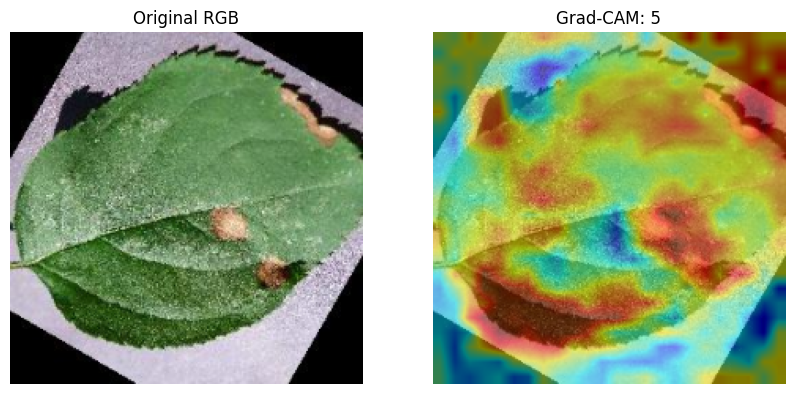

In [72]:
plt.figure(figsize=(10,5))

# Original image
plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.axis('off')
plt.title('Original RGB')

# Grad-CAM overlay
plt.subplot(1,2,2)
plt.imshow(superimposed)
plt.axis('off')
plt.title(f'Grad-CAM: {predicted_class_name}')
plt.show()
